<a href="https://colab.research.google.com/github/RohanKumar0095/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# === Rebuild ML-08 pipeline in this notebook ===
from google.colab import userdata
from huggingface_hub import login, list_repo_files, hf_hub_download
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score
import os, json

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

def load_month_agg(month_str):
    files = list_repo_files("FlyRank/internship-warehouse", repo_type="dataset")
    month_files = [f for f in files if f"fact_content_daily_performance/month={month_str}" in f]
    local_paths = [
        hf_hub_download(repo_id="FlyRank/internship-warehouse", filename=f, repo_type="dataset")
        for f in month_files
    ]
    raw = pd.concat([pd.read_parquet(p) for p in local_paths], ignore_index=True)
    gsc = raw[raw['gsc_data_available'] == True].copy()
    agg = gsc.groupby(['client_hash_id', 'content_hash_id']).agg(
        days_with_data=('report_date', 'nunique'),
        total_impressions=('gsc_impressions', 'sum'),
        total_clicks=('gsc_clicks', 'sum'),
        avg_position=('gsc_avg_position', 'mean')
    ).reset_index()
    agg = agg[agg['total_impressions'] > 0].copy()
    agg['ctr'] = agg['total_clicks'] / agg['total_impressions']
    return agg

march = load_month_agg("2026-03")
april = load_month_agg("2026-04")

pos_bins = [0, 3, 10, 20, 50, 1000]
pos_labels = ['1-3', '4-10', '11-20', '21-50', '51+']

def add_ctr_gap(agg):
    agg = agg.copy()
    agg['position_bucket'] = pd.cut(agg['avg_position'], bins=pos_bins, labels=pos_labels)
    bucket_totals = agg.groupby('position_bucket', observed=True).agg(
        clicks_sum=('total_clicks', 'sum'), impressions_sum=('total_impressions', 'sum')
    )
    bucket_totals['expected_ctr'] = bucket_totals['clicks_sum'] / bucket_totals['impressions_sum']
    agg['expected_ctr'] = agg['position_bucket'].map(bucket_totals['expected_ctr']).astype(float)
    agg['ctr'] = agg['ctr'].astype(float)
    agg['ctr_gap'] = agg['expected_ctr'] - agg['ctr']
    agg['ctr_ratio'] = agg['ctr'] / agg['expected_ctr'].replace(0, np.nan)
    return agg

march = add_ctr_gap(march)
april = add_ctr_gap(april)
april['label_still_underperforming'] = (
    (april['total_impressions'] >= 1000) & (april['ctr_ratio'] < 0.5)
).astype(int)

def score_row(row):
    if row['total_impressions'] >= 1000 and pd.notnull(row['ctr_ratio']) and row['ctr_ratio'] < 0.5:
        return row['ctr_gap'] * row['total_impressions']
    return 0

march['baseline_score'] = march.apply(score_row, axis=1)

merged = march.merge(
    april[['client_hash_id', 'content_hash_id', 'label_still_underperforming']],
    on=['client_hash_id', 'content_hash_id'],
    how='inner'
)

feature_cols = ['total_impressions', 'total_clicks', 'avg_position', 'ctr',
                 'ctr_gap', 'ctr_ratio', 'days_with_data']
merged_model = merged.dropna(subset=feature_cols + ['label_still_underperforming']).copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(merged_model, groups=merged_model['client_hash_id']))
train_df = merged_model.iloc[train_idx]
test_df = merged_model.iloc[test_idx]

X_train, y_train = train_df[feature_cols], train_df['label_still_underperforming']
X_test, y_test = test_df[feature_cols], test_df['label_still_underperforming']

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
test_df = test_df.copy()
test_df['model_score'] = model.predict_proba(X_test)[:, 1]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

results = []
for k in [20, 50, 100]:
    p_baseline = precision_at_k(test_df['baseline_score'], test_df['label_still_underperforming'], k)
    p_model = precision_at_k(test_df['model_score'], test_df['label_still_underperforming'], k)
    results.append({'k': k, 'baseline_precision': p_baseline, 'model_precision': p_model, 'base_rate': y_test.mean()})

comparison_table = pd.DataFrame(results)
print("Rebuild complete.")
print(f"merged_model: {len(merged_model)} rows")
print(comparison_table)

Rebuild complete.
merged_model: 157790 rows
     k  baseline_precision  model_precision  base_rate
0   20                0.95             0.95    0.10218
1   50                0.98             0.80    0.10218
2  100                0.92             0.78    0.10218


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# Ranking rule: use baseline_score, not model_score.
# ML-09 showed the rule-based baseline beats the logistic model at precision@50
# (0.98 vs 0.80) and precision@100 (0.92 vs 0.78) - the K sizes an editor actually
# works through - so the baseline is the honest choice for the production queue.

queue = merged_model.copy()

def reason_code(row):
    codes = []
    if row['position_bucket'] in ['1-3', '4-10']:
        codes.append('high_position_low_ctr')      # ranks well, still underclicked - snippet/title problem
    elif row['position_bucket'] in ['21-50', '51+']:
        codes.append('deep_position_visible')       # ranks poorly but still has real impressions
    else:
        codes.append('mid_position_ctr_gap')
    if row['total_impressions'] >= 5000:
        codes.append('high_volume')
    if pd.notnull(row['ctr_ratio']) and row['ctr_ratio'] < 0.3:
        codes.append('severe_ctr_gap')
    elif pd.notnull(row['ctr_ratio']) and row['ctr_ratio'] < 0.5:
        codes.append('moderate_ctr_gap')
    return '|'.join(codes)

queue['reason_code'] = queue.apply(reason_code, axis=1)
queue['action'] = 'review_title_and_snippet'  # single action type - see Section 2 for why

queue_ranked = queue[queue['baseline_score'] > 0].sort_values('baseline_score', ascending=False).reset_index(drop=True)
queue_ranked['rank'] = queue_ranked.index + 1

print(f"Total items in matched March->April dataset: {len(queue)}")
print(f"Flagged (baseline_score > 0): {len(queue_ranked)}  ({len(queue_ranked)/len(queue):.1%} of dataset)")
print()
print("Top 15 ranked items:")
print(queue_ranked[['rank', 'client_hash_id', 'content_hash_id', 'position_bucket',
                     'ctr_ratio', 'total_impressions', 'baseline_score', 'reason_code']]
      .head(15).to_string(index=False))
print()
print("Reason code frequency across the full flagged queue:")
print(queue_ranked['reason_code'].value_counts())

Total items in matched March->April dataset: 157790
Flagged (baseline_score > 0): 17885  (11.3% of dataset)

Top 15 ranked items:
 rank          client_hash_id          content_hash_id position_bucket  ctr_ratio  total_impressions  baseline_score                                        reason_code
    1 client_23a62021009f63c4 content_44f34c0a90047651            4-10   0.034885             212404      663.966421   high_position_low_ctr|high_volume|severe_ctr_gap
    2 client_e547b89c05043229 content_8d7d99f109e19aa2             1-3   0.349577             203497      537.712743 high_position_low_ctr|high_volume|moderate_ctr_gap
    3 client_73cda7b4e4f265ea content_8e1334d6356668e3            4-10   0.002287             134984      436.206735   high_position_low_ctr|high_volume|severe_ctr_gap
    4 client_62f4a7e64f5e0096 content_34a70fea29d15f24            4-10   0.092826             143019      420.231717   high_position_low_ctr|high_volume|severe_ctr_gap
    5 client_73cda7b4e4f265ea 

**The queue.** Every item scored `baseline_score > 0` is ranked highest-score-first, using the ML-07/ML-08 rule (`ctr_gap × total_impressions`, gated at `ctr_ratio < 0.5` and 1,000+ impressions). This isn't the model — it's the rule-based baseline — because ML-09's honest, grouped-split comparison showed the baseline beats the logistic model at precision@50 (0.98 vs 0.80) and precision@100 (0.92 vs 0.78). An editor working through this list in order gets more real hits per hour from the baseline than from the model.

17,885 items, out of 157,790 matched March→April items (11.3%), meet the CTR-underperformance threshold. Reason codes combine three signals: position tier (high-position-low-CTR = a snippet/title problem on a page that already ranks; deep-position-visible = a page with real impressions despite weak ranking), volume (`high_volume` = 5,000+ impressions, meaning any fix has outsized reach), and severity (`moderate_ctr_gap` vs `severe_ctr_gap`, split at ctr_ratio 0.3). `high_position_low_ctr|severe_ctr_gap` is the single most frequent pattern (5,255 items, ~29% of the flagged queue) — a page already ranking on page 1 (positions 1–10) with a severely underperforming CTR (ratio < 0.3), below the 5,000-impression volume cutoff. This is where editor time is most needed: these are the cheapest, highest-leverage fixes (title/snippet review on already-ranking pages), and they make up the largest single share of the queue.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use.** This queue is decision-support for a content editor or SEO strategist deciding which pages to review first out of a large portfolio. The output is a ranked list with reason codes — not an automated action, and not a guarantee of recovery. It answers "which page should a human look at first?", not "what should be changed on this page?" or "will this page improve?"

**Who acts on it.** A content editor or on-page SEO reviewer, working through the ranked list top-down, using the reason code to decide what kind of review each item needs (title/snippet rewrite for `high_position_low_ctr`, broader content or relevance review for `deep_position_visible`).

**Where it stops being valid:**
- **One client portfolio, one month-pair (March → April 2026).** Scores and thresholds were tuned and validated on this specific dataset; they are not guaranteed to hold on a different portfolio, industry mix, or time period without re-validation.
- **`ctr_ratio < 0.5` is a threshold choice, not a natural cutoff.** A page at 0.51 is treated as fine; a page at 0.49 is flagged. Borderline cases need human judgment, not blind trust in the score.
- **The queue reflects correlation, not a guarantee of cause.** A high `baseline_score` means the page's CTR is far below what similar-position pages get — it does not diagnose *why* (bad title? wrong search intent? seasonal dip?). That diagnosis is the human's job.
- **No forward guarantee.** ML-09's validation showed the rule holds up reasonably at precision@50/100 on a held-out set of *clients*, not held-out *time*. Performance should be re-checked each time it's applied to a new month.
- **Small samples produce noisy scores.** Per the auditing-signals discipline, any reason-code bucket with under ~50 items should be treated cautiously, not read as a confirmed pattern.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [3]:
# Top 20 for hand review, per the building-baselines skill: this is where bad
# logic in a rule shows itself, so review it before trusting the list at scale.

top_20_review = queue_ranked.head(20)[
    ['rank', 'client_hash_id', 'content_hash_id', 'position_bucket',
     'avg_position', 'ctr', 'expected_ctr', 'ctr_ratio', 'total_impressions', 'reason_code']
]
print(top_20_review.to_string(index=False))

 rank          client_hash_id          content_hash_id position_bucket  avg_position      ctr  expected_ctr  ctr_ratio  total_impressions                                        reason_code
    1 client_23a62021009f63c4 content_44f34c0a90047651            4-10      7.346909 0.000113      0.003239   0.034885             212404   high_position_low_ctr|high_volume|severe_ctr_gap
    2 client_e547b89c05043229 content_8d7d99f109e19aa2             1-3      2.563756 0.001420      0.004063   0.349577             203497 high_position_low_ctr|high_volume|moderate_ctr_gap
    3 client_73cda7b4e4f265ea content_8e1334d6356668e3            4-10      4.545582 0.000007      0.003239   0.002287             134984   high_position_low_ctr|high_volume|severe_ctr_gap
    4 client_62f4a7e64f5e0096 content_34a70fea29d15f24            4-10      3.219473 0.000301      0.003239   0.092826             143019   high_position_low_ctr|high_volume|severe_ctr_gap
    5 client_73cda7b4e4f265ea content_fec55986a1868d62 

**Human review checklist.** Before acting on any item in this queue, a reviewer should check:
1. **Does the page still exist and is it live?** (Content can be removed/redirected after the March snapshot.)
2. **Is the CTR gap explainable by something outside the page itself** — a SERP feature change, a seasonal query, a brand-name cannibalization, a recent algorithm update — rather than a fixable title/snippet issue?
3. **Is `total_impressions` real search demand, or a spike/anomaly** (bot traffic, a one-off viral mention) that inflated the score?
4. **Does the reason code match what the reviewer sees on the page?** If `high_position_low_ctr` is assigned but the title already looks strong, that's a signal the automated reason code missed something — worth a note back into the process, not a silent skip.

**What should NOT be automated:**
- **Auto-editing titles, meta descriptions, or content** based on the score alone. The score identifies *where* to look, never *what* to change.
- **Auto-publishing or auto-deploying any change** without editorial sign-off — this queue has no page-content understanding, only aggregate click/position numbers.
- **Client-facing reporting or client communication** built directly from `baseline_score` without a human first confirming the underlying cause. Presenting an unreviewed score as a diagnosis risks overclaiming to a client, which the writing-honest-claims discipline explicitly rules out.
- **Using this queue to justify resourcing or performance-review decisions** about content teams — it measures pages, not people, and doing so would extend the tool well past what one month-pair of one portfolio can support.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**What would tell us the recommendations went stale:**

1. **Base rate drift.** April's `label_still_underperforming` base rate was 10.2%. If a future month's matched base rate moves sharply (e.g., below 5% or above 20%), the threshold (`ctr_ratio < 0.5`, 1,000+ impressions) may no longer separate real underperformers from noise — re-tune before trusting the queue.
2. **Precision@K decay.** If a future month's precision@50 (measured the same way as ML-09, on a fresh matched period) drops well below the 0.98 seen here, that's the clearest signal the rule needs review — not a silent continued use.
3. **Client/content churn.** ML-08 found 10.3% of March items had no April match (churned clients or removed content). A rising churn rate across future periods means the matched dataset the rule is validated on is shrinking or shifting, and revalidation is due.
4. **Position-bucket CTR shift.** The `expected_ctr` baseline is computed fresh from each month's own data, so it self-adjusts somewhat — but a large swing in a bucket's `expected_ctr` between months (e.g., a Google SERP layout change altering top-3 CTR broadly) is worth a manual check, since it would move every score in that bucket at once.
5. **Cadence.** Recompute this queue monthly, using the same month-over-month matching logic as March→April. Recheck precision@K against real outcomes at least quarterly, since that is the only way to catch decay 2 or 3 above before it silently degrades editor trust in the list.

**Cost/value framing.** A false positive (page flagged, editor time spent, no real problem) costs editor review time — cheap relative to a missed real decline. A false negative (page underperforming, not flagged) costs a page continuing to lose clicks silently. Given that asymmetry, and that precision@50 (0.98) is already high, the current threshold favors *not missing* real underperformers over avoiding a small amount of wasted review time — a defensible trade-off for a decision-support tool reviewed by humans before any action is taken.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Saved queue: work/outputs/w07_action_queue.csv (17885 rows)
Saved metrics: work/outputs/w07_metrics_summary.json


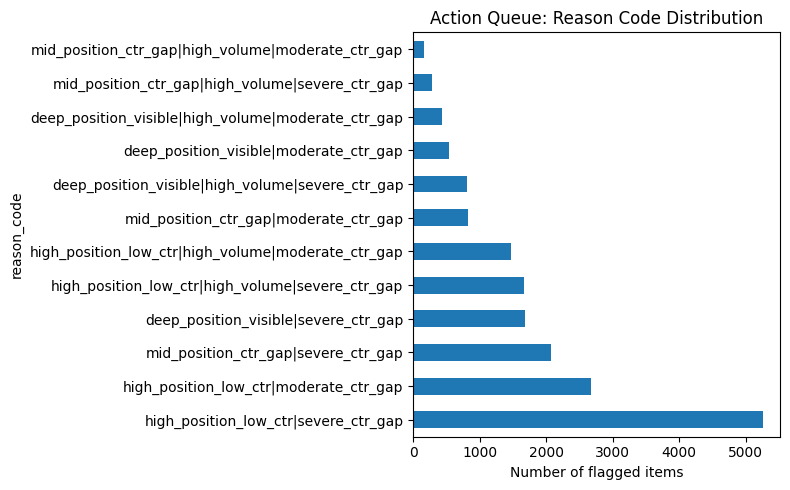

Saved figure: work/figures/w07_reason_code_distribution.png


In [4]:
import os
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 1. Ranked queue CSV (stays out of git by design - CI leak-guard blocks data files)
queue_export = queue_ranked[['rank', 'client_hash_id', 'content_hash_id', 'position_bucket',
                              'avg_position', 'ctr', 'expected_ctr', 'ctr_ratio',
                              'total_impressions', 'baseline_score', 'reason_code', 'action']]
queue_export.to_csv('work/outputs/w07_action_queue.csv', index=False)
print(f"Saved queue: work/outputs/w07_action_queue.csv ({len(queue_export)} rows)")

# 2. Metrics JSON (this DOES get committed - it's the receipt for the paper's numbers)
metrics_summary = {
    "period": "March 2026 -> April 2026",
    "matched_dataset_rows": int(len(merged_model)),
    "flagged_queue_rows": int(len(queue_ranked)),
    "flag_rate": round(len(queue_ranked) / len(merged_model), 4),
    "april_base_rate": round(float(y_test.mean()), 4),
    "baseline_precision_at_k": {
        "20": float(comparison_table.loc[comparison_table['k'] == 20, 'baseline_precision'].values[0]),
        "50": float(comparison_table.loc[comparison_table['k'] == 50, 'baseline_precision'].values[0]),
        "100": float(comparison_table.loc[comparison_table['k'] == 100, 'baseline_precision'].values[0]),
    },
    "model_precision_at_k": {
        "20": float(comparison_table.loc[comparison_table['k'] == 20, 'model_precision'].values[0]),
        "50": float(comparison_table.loc[comparison_table['k'] == 50, 'model_precision'].values[0]),
        "100": float(comparison_table.loc[comparison_table['k'] == 100, 'model_precision'].values[0]),
    },
    "model_auc_grouped_split": round(float(roc_auc_score(y_test, test_df['model_score'])), 4),
    "reason_code_counts": queue_ranked['reason_code'].value_counts().to_dict()
}

with open('work/outputs/w07_metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print("Saved metrics: work/outputs/w07_metrics_summary.json")

# 3. Reusable figure: reason code distribution (bar chart) -> work/figures/ (this DOES get committed)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
queue_ranked['reason_code'].value_counts().plot(kind='barh', ax=ax)
ax.set_xlabel('Number of flagged items')
ax.set_title('Action Queue: Reason Code Distribution')
plt.tight_layout()
plt.savefig('work/figures/w07_reason_code_distribution.png', dpi=150)
plt.show()
print("Saved figure: work/figures/w07_reason_code_distribution.png")

**Exports for the paper.** `work/outputs/w07_action_queue.csv` holds the full ranked queue (regenerated by this notebook, not committed — the CI leak-guard blocks data files). `work/outputs/w07_metrics_summary.json` is committed and holds every number this and the paper's Results section will cite: matched dataset size, flag rate, base rate, precision@K for both baseline and model, grouped-split AUC, and reason code counts — these are the receipts the paper's claims trace back to. `work/figures/w07_reason_code_distribution.png` is committed and reusable directly in the paper's Results or Recommendations section.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.